In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sklearn
import os
import sys
import time
from tqdm.auto import tqdm
import torch.nn.functional as F
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

cuda:0


In [ ]:
import openpyxl
fpath = Path(r"./result.xlsx")
df = pd.read_excel(fpath) 


In [3]:
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams["axes.unicode_minus"] = False
# 查看数据
print(df.shape)
print(df.head())

(400, 7)
   date1      close      arima       lstm     lstm_1   cnn_lstm  attention
0  23099  17.862000  24.208820  17.331394  17.568944  17.377914  17.202854
1  23100  18.129999  24.230297  17.353370  17.821479  17.425635  17.361330
2  23103  18.266001  24.247976  17.398909  18.109119  17.553314  17.679367
3  23104  18.202000  24.226761  17.480864  18.336360  17.704698  17.967109
4  23105  17.930000  24.202171  17.574410  18.408906  17.861338  18.166784


In [ ]:
close = df["close"].values
arima = df["arima"].values
lstm = df["lstm"].values
lstm_1 = df["lstm_1"].values
cnn_lstm = df["cnn_lstm"].values
attention = df["attention"].values

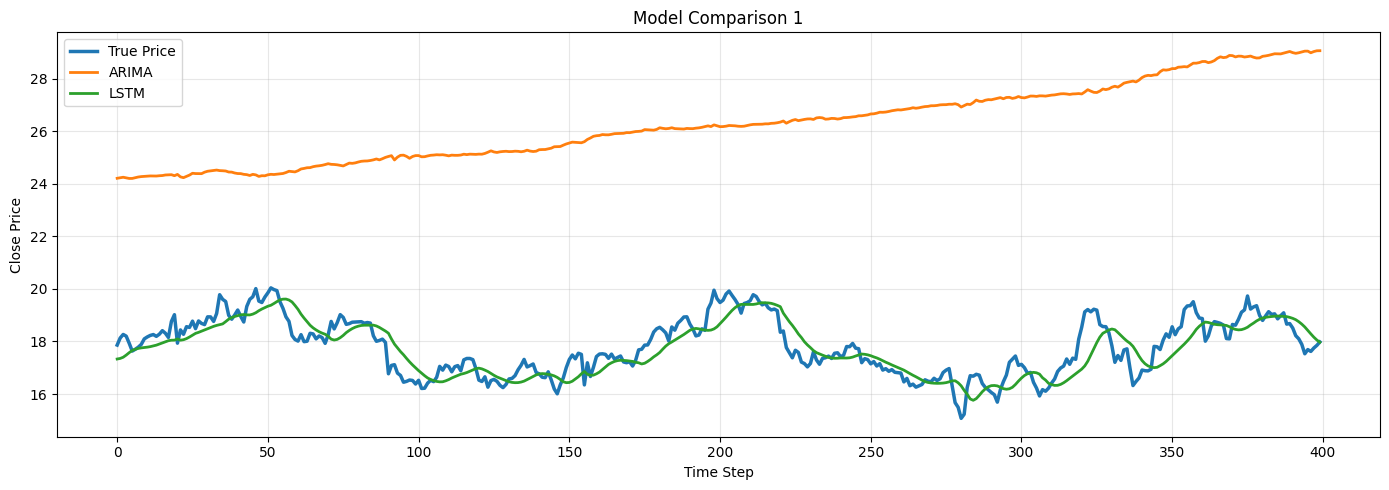

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(close, label='True Price', linewidth=2.5)
plt.plot(arima, label='ARIMA', linewidth=2)
plt.plot(lstm, label='LSTM', linewidth=2)
plt.title('Model Comparison 1')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

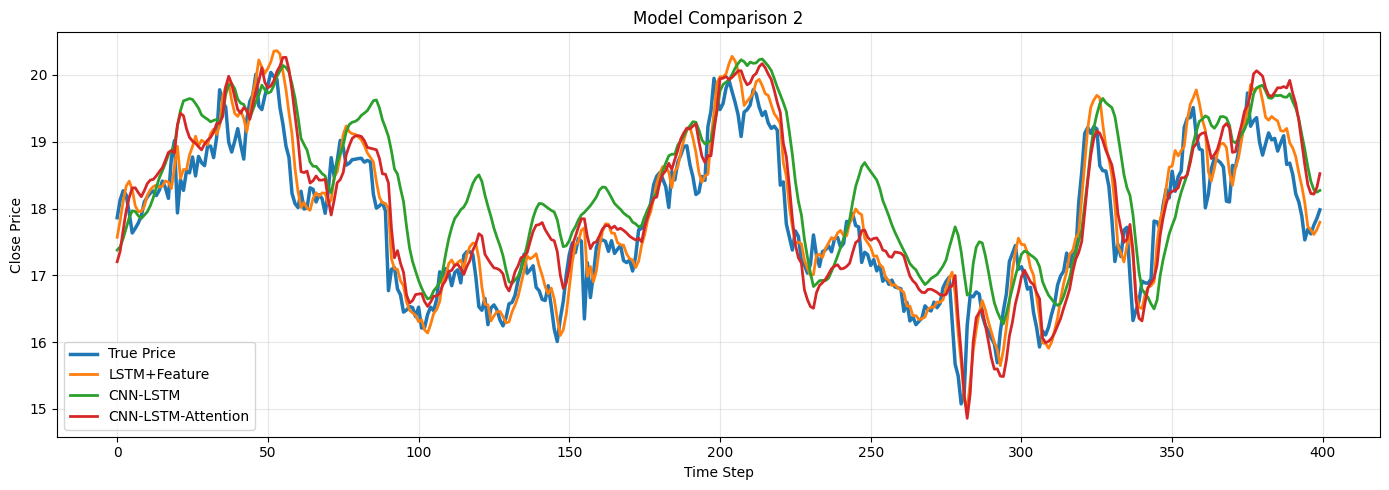

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(close, label='True Price', linewidth=2.5)
plt.plot(lstm_1, label='LSTM+Feature', linewidth=2)
plt.plot(cnn_lstm, label='CNN-LSTM', linewidth=2)
plt.plot(attention, label='CNN-LSTM-Attention', linewidth=2)
plt.title('Model Comparison 2')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.signal import correlate

# 评价指标函数
def metric(y_true, y_pred):
    # 基础指标
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # 方向准确率 DA
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    da = np.mean((true_diff * pred_diff) > 0) * 100
    
    # 最优滞后步长 lag
    corr = correlate(y_true - np.mean(y_true), y_pred - np.mean(y_pred), mode='full')
    lag = np.argmax(corr) - (len(y_true) - 1)
    
    return rmse, r2, mape, da, lag

models = {
    "ARIMA": arima,
    "LSTM": lstm,
    "LSTM+Feature": lstm_1,
    "CNN-LSTM": cnn_lstm,
    "Attention(Improved)": attention
}

# 输出结果
print("模型\t\t\tRMSE\t\tR2\tMAPE\t\tDA\t滞后步长")
print("-"*60)
for name, pred in models.items():
    rmse, r2, mape, da, lag = metric(close, pred)
    print(f"{name:18}\t{rmse:.4f}\t{r2:9.4f}\t{mape:7.2f}%\t{da:.2f}%\t{lag}")

模型			RMSE		R2	MAPE		DA	滞后步长
------------------------------------------------------------
ARIMA             	8.6368	 -63.8641	  47.93%	52.13%	-315
LSTM              	0.6021	   0.6848	   2.68%	50.13%	-6
LSTM+Feature      	0.3858	   0.8706	   1.65%	53.38%	-1
CNN-LSTM          	0.8351	   0.3936	   3.92%	53.38%	-4
Attention(Improved)	0.5818	   0.7057	   2.66%	52.88%	-2
